In [1]:
# !pip install tensorflow scikit-learn seaborn xgboost shap --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from xgboost import XGBRegressor

# ── Global dark aerospace theme ─────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#c9d1d9',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#c9d1d9',
    'grid.color':       '#21262d',
    'grid.linewidth':   0.6,
    'legend.facecolor': '#161b22',
    'legend.edgecolor': '#30363d',
    'font.family':      'monospace',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
    'xtick.labelsize':  9,
    'ytick.labelsize':  9,
})

BLUE   = '#58a6ff'
ORANGE = '#f78166'
GREEN  = '#3fb950'
YELLOW = '#e3b341'
PURPLE = '#bc8cff'
TEAL   = '#39d353'
GRAY   = '#8b949e'

print("Imports OK | TF:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))


Imports OK | TF: 2.19.0
GPU: []


In [3]:
from google.colab import files
print("Upload 'train_FD001_prepared.csv'")
uploaded = files.upload()

df = pd.read_csv("train_FD001_prepared.csv")
print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} cols | "
      f"Engines: {df['unit_nr'].nunique()} | Max cycle: {df['cycle'].max()}")
df.head()


Upload 'train_FD001_prepared.csv'


Saving train_FD001_prepared.csv to train_FD001_prepared.csv
Loaded: 20,631 rows x 13 cols | Engines: 100 | Max cycle: 362


,unit_nr,cycle,sensor2,sensor3,sensor4,sensor7,sensor8,sensor9,sensor15,sensor17,sensor20,sensor21,RUL
0,1,1,-1.721725,-0.134255,-0.925936,1.121141,-0.516338,-0.862813,-0.603816,-0.781710,1.348493,1.194427,191
1,1,2,-1.061780,0.211528,-0.643726,0.431930,-0.798093,-0.958818,-0.275852,-0.781710,1.016528,1.236922,190
2,1,3,-0.661813,-0.413166,-0.525953,1.008155,-0.234584,-0.557139,-0.649144,-2.073094,0.739891,0.503423,189
3,1,4,-0.661813,-1.261314,-0.784831,1.222827,0.188048,-0.713826,-1.971665,-0.781710,0.352598,0.777792,188
4,1,5,-0.621816,-1.251528,-0.301518,0.714393,-0.516338,-0.457059,-0.339845,-0.136018,0.463253,1.059552,187


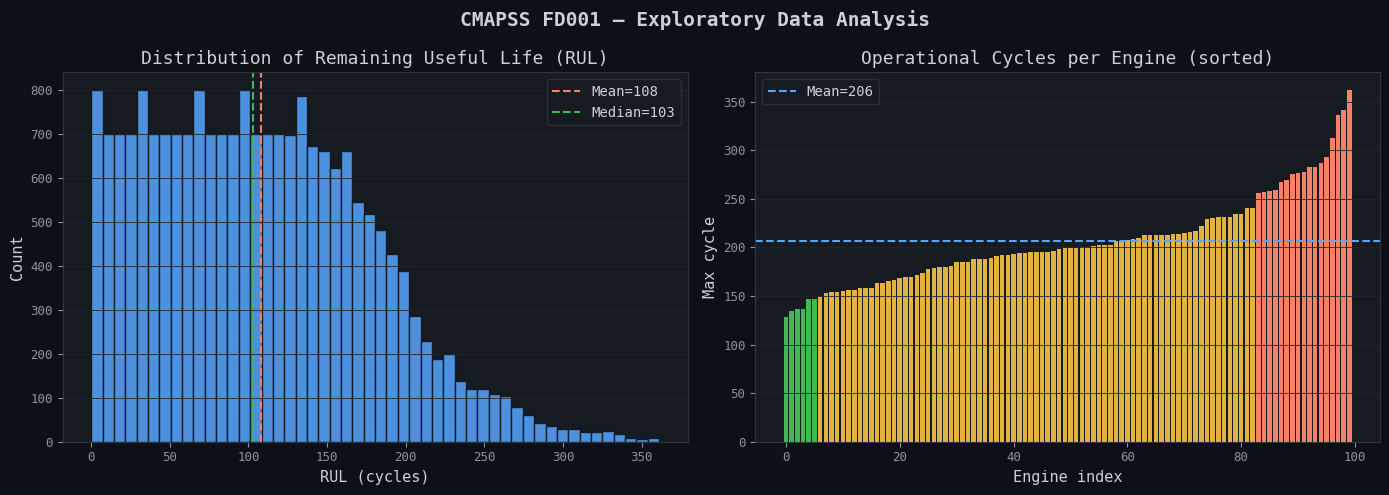

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0d1117')
fig.suptitle('CMAPSS FD001 — Exploratory Data Analysis', fontsize=14,
             color='#c9d1d9', fontweight='bold')

ax = axes[0]
ax.hist(df['RUL'], bins=50, color=BLUE, edgecolor='#0d1117', alpha=0.85)
ax.axvline(df['RUL'].mean(),   color=ORANGE, linestyle='--', linewidth=1.5,
           label=f"Mean={df['RUL'].mean():.0f}")
ax.axvline(df['RUL'].median(), color=GREEN,  linestyle='--', linewidth=1.5,
           label=f"Median={df['RUL'].median():.0f}")
ax.set_title('Distribution of Remaining Useful Life (RUL)')
ax.set_xlabel('RUL (cycles)'); ax.set_ylabel('Count')
ax.legend(); ax.grid(True, axis='y')

ax2 = axes[1]
cpe = df.groupby('unit_nr')['cycle'].max().sort_values()
bar_cols = [GREEN if v < 150 else YELLOW if v < 250 else ORANGE for v in cpe]
ax2.bar(range(len(cpe)), cpe.values, color=bar_cols, width=0.8)
ax2.axhline(cpe.mean(), color=BLUE, linestyle='--', linewidth=1.5,
            label=f"Mean={cpe.mean():.0f}")
ax2.set_title('Operational Cycles per Engine (sorted)')
ax2.set_xlabel('Engine index'); ax2.set_ylabel('Max cycle')
ax2.legend(); ax2.grid(True, axis='y')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()


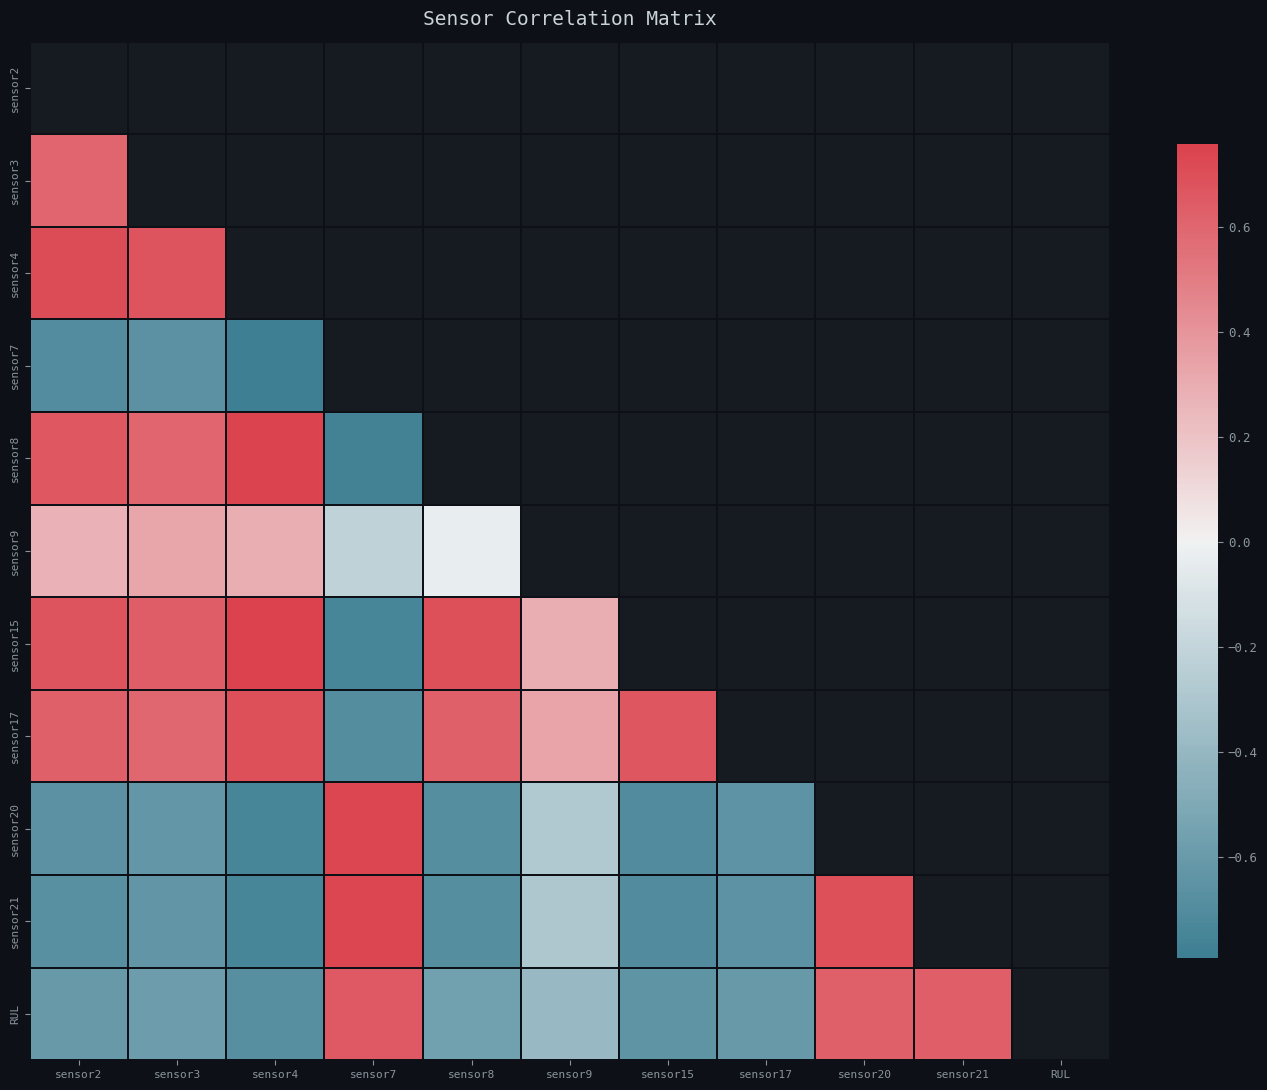

In [5]:
sensor_cols = [c for c in df.columns if c not in ['unit_nr', 'cycle']]
corr = df[sensor_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
fig.patch.set_facecolor('#0d1117')

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap=sns.diverging_palette(220, 10, as_cmap=True),
            center=0, annot=False, linewidths=0.3, linecolor='#0d1117',
            cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Sensor Correlation Matrix', fontsize=14, pad=12, color='#c9d1d9')
ax.tick_params(labelsize=8)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()


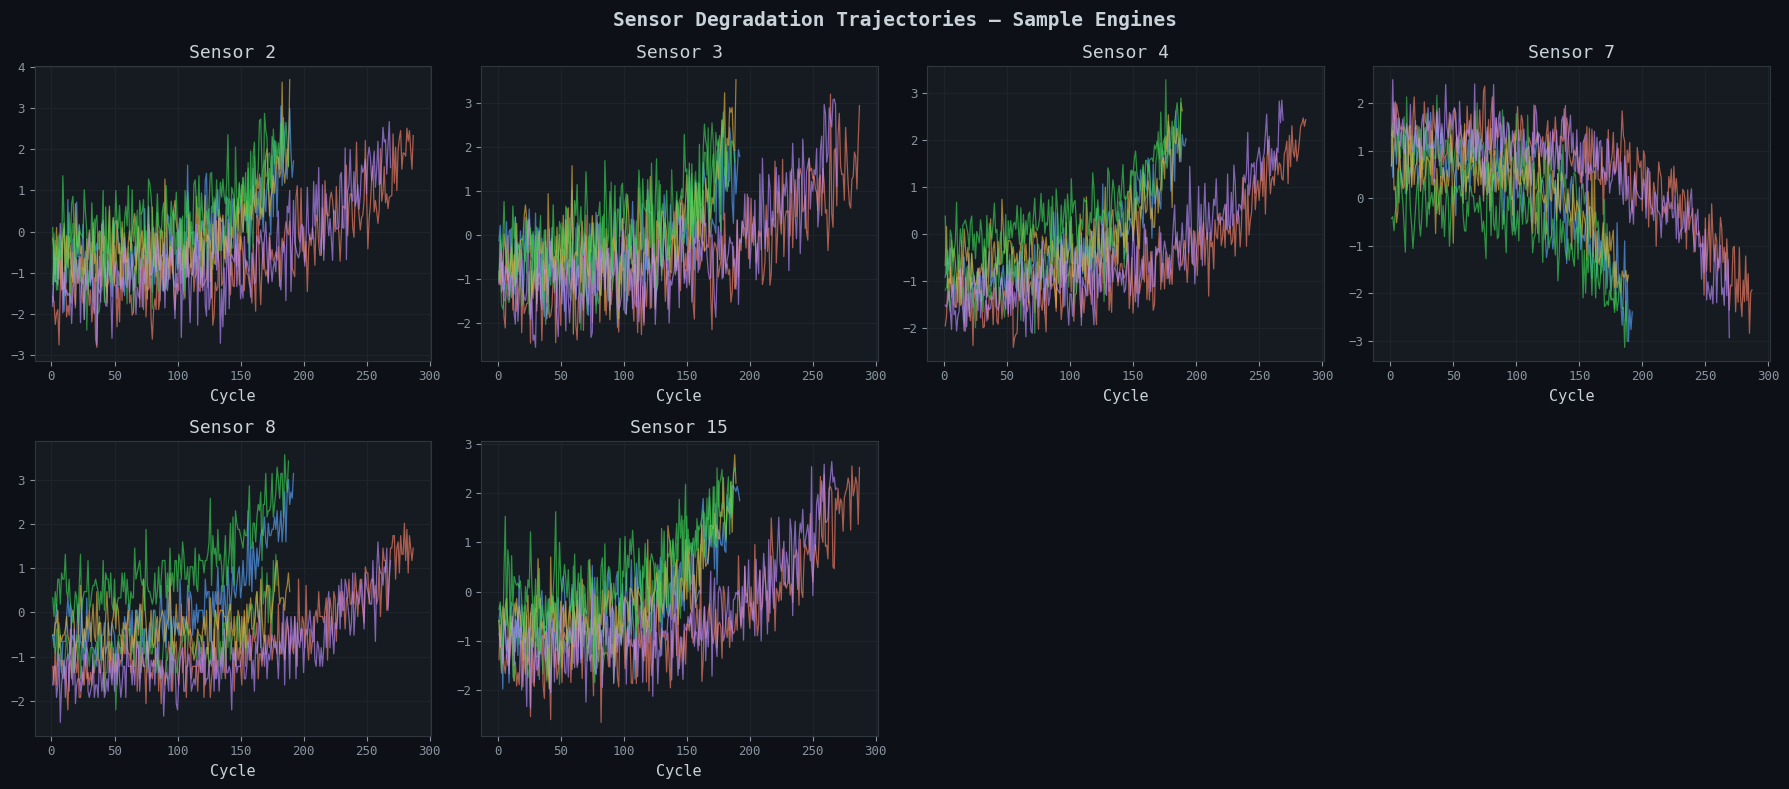

In [6]:
KEY_SENSORS = ['sensor2','sensor3','sensor4','sensor7',
               'sensor8','sensor11','sensor12','sensor15']
KEY_SENSORS = [s for s in KEY_SENSORS if s in df.columns]
PALETTE = [BLUE, ORANGE, GREEN, YELLOW, PURPLE, TEAL, '#ff7b72', '#ffa657']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.patch.set_facecolor('#0d1117')
fig.suptitle('Sensor Degradation Trajectories — Sample Engines',
             fontsize=14, color='#c9d1d9', fontweight='bold')
axes = axes.flatten()

sample_engines = df['unit_nr'].unique()[:6]
for idx, sensor in enumerate(KEY_SENSORS):
    ax = axes[idx]
    for eid, eng_id in enumerate(sample_engines):
        eng = df[df['unit_nr'] == eng_id]
        ax.plot(eng['cycle'], eng[sensor], alpha=0.65, linewidth=0.9,
                color=PALETTE[eid % len(PALETTE)])
    ax.set_title(sensor.replace('sensor', 'Sensor '))
    ax.set_xlabel('Cycle'); ax.grid(True)

for ax in axes[len(KEY_SENSORS):]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig('sensor_degradation.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()


In [7]:
df['RUL'] = df['RUL'].clip(upper=125)

features = ['sensor2','sensor3','sensor4','sensor7','sensor8',
            'sensor9','sensor15','sensor17','sensor20','sensor21']
features = [f for f in features if f in df.columns]

for col in features:
    df[col+'_mean'] = df.groupby('unit_nr')[col].transform(
        lambda x: x.rolling(10, min_periods=1).mean())
    df[col+'_std']  = df.groupby('unit_nr')[col].transform(
        lambda x: x.rolling(10, min_periods=1).std().fillna(0))

print("Feature engineering done. RUL stats:")
print(df['RUL'].describe().round(2))


Feature engineering done. RUL stats:
count    20631.00
mean        86.83
std         41.67
min          0.00
25%         51.00
50%        103.00
75%        125.00
max        125.00
Name: RUL, dtype: float64


In [8]:
sensor_feat_cols = [c for c in df.columns
                    if c not in ['unit_nr','cycle','RUL']
                    and not c.endswith('_mean') and not c.endswith('_std')]

scaler_lstm = MinMaxScaler()
scaled      = scaler_lstm.fit_transform(df[sensor_feat_cols])
scaled_df   = pd.DataFrame(scaled, columns=sensor_feat_cols)
scaled_df['unit_nr'] = df['unit_nr'].values
scaled_df['cycle']   = df['cycle'].values
scaled_df['RUL']     = df['RUL'].values

SEQ_LEN = 30

def create_sequences(data, seq_len):
    X_list, y_list = [], []
    for unit in data['unit_nr'].unique():
        eng   = data[data['unit_nr'] == unit].reset_index(drop=True)
        feats = eng.drop(['unit_nr','cycle','RUL'], axis=1).values
        rul   = eng['RUL'].values
        for i in range(len(eng) - seq_len):
            X_list.append(feats[i:i+seq_len])
            y_list.append(rul[i+seq_len])
    return np.array(X_list), np.array(y_list)

X, y = create_sequences(scaled_df, SEQ_LEN)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")


X_train: (14104, 30, 10) | X_test: (3527, 30, 10)


In [9]:
tf.random.set_seed(42)

lstm_model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.3),
    LSTM(64),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1)
], name='RUL_LSTM')

lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
lstm_model.summary()

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

print("\nTraining LSTM...")
history = lstm_model.fit(
    X_train, y_train, epochs=40, batch_size=64,
    validation_split=0.2, callbacks=callbacks, verbose=1)
print("LSTM training complete.")


Model: "RUL_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 128)        │        71,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,689 (479.25 KB)

 Trainable params: 122,689 (479.25 KB)

 Non-trainable params: 0 (0.00 B)


Training LSTM...
Epoch 1/40
177/177 ━━━━━━━━━━━━━━━━━━━━ 20s 94ms/step - loss: 3828.8381 - mae: 51.9274 - val_loss: 1761.5537 - val_mae: 37.5084 - learning_rate: 0.0010
Epoch 2/40
177/177 ━━━━━━━━━━━━━━━━━━━━ 18s 101ms/step - loss: 1777.2366 - mae: 37.2562 - val_loss: 1758.2103 - val_mae: 37.3626 - learning_rate: 0.0010
Epoch 3/40
177/177 ━━━━━━━━━━━━━━━━━━━━ 16s 92ms/step - loss: 1789.6765 - mae: 37.3747 - val_loss: 1758.4518 - val_mae: 37.3860 - learning_rate: 0.0010
Epoch 4/40
177/177 ━━━━━━━━━━━━━━━━━━━━ 17s 95ms/step - loss: 1783.9196 - mae: 37.3445 - val_loss: 1758.3070 - val_mae: 37.3737 - learning_rate: 0.0010
Epoch 5/40
176/177 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 1781.5412 - mae: 37.2894
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
177/177 ━━━━━━━━━━━━━━━━━━━━ 21s 98ms/step - loss: 1786.8474 - mae: 37.3547 - val_loss: 1758.3313 - val_mae: 37.3761 - learning_rate: 0.0010
Epoch 6/40
177/177 ━━━━━━━━━━━━━━━━━━━━ 17s 97ms/step - loss: 1788.947

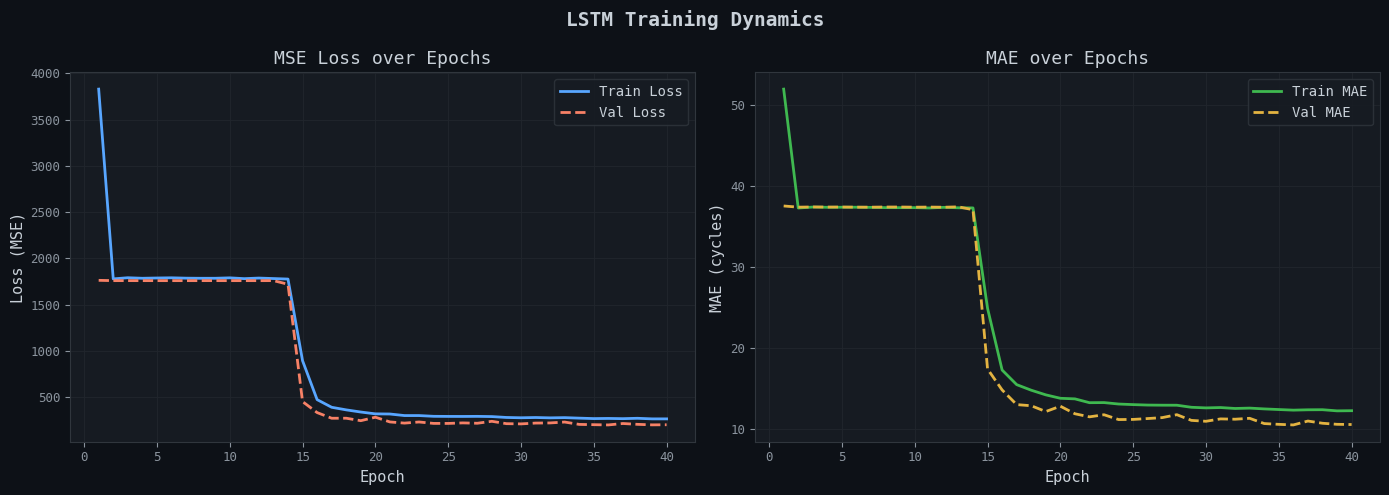

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0d1117')
fig.suptitle('LSTM Training Dynamics', fontsize=14, color='#c9d1d9', fontweight='bold')

ep = range(1, len(history.history['loss'])+1)

axes[0].plot(ep, history.history['loss'],     color=BLUE,   lw=2, label='Train Loss')
axes[0].plot(ep, history.history['val_loss'], color=ORANGE, lw=2, label='Val Loss', ls='--')
axes[0].set_title('MSE Loss over Epochs'); axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(ep, history.history['mae'],     color=GREEN,  lw=2, label='Train MAE')
axes[1].plot(ep, history.history['val_mae'], color=YELLOW, lw=2, label='Val MAE', ls='--')
axes[1].set_title('MAE over Epochs'); axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE (cycles)'); axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig('lstm_training.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()


111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step
LSTM  RMSE=14.73  MAE=10.89  R2=0.8764


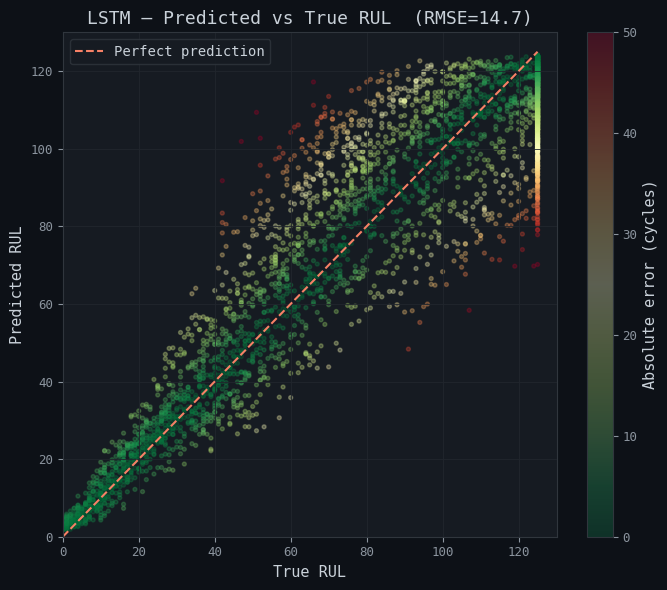

In [11]:
lstm_preds = lstm_model.predict(X_test).flatten()
lstm_rmse  = np.sqrt(mean_squared_error(y_test, lstm_preds))
lstm_mae   = mean_absolute_error(y_test, lstm_preds)
lstm_r2    = r2_score(y_test, lstm_preds)

print(f"LSTM  RMSE={lstm_rmse:.2f}  MAE={lstm_mae:.2f}  R2={lstm_r2:.4f}")

fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor('#0d1117')

sc = ax.scatter(y_test, lstm_preds, alpha=0.3, s=8,
                c=np.abs(y_test - lstm_preds), cmap='RdYlGn_r', vmin=0, vmax=50)
ax.plot([0,125],[0,125], color=ORANGE, lw=1.5, ls='--', label='Perfect prediction')
cb = plt.colorbar(sc, ax=ax)
cb.set_label('Absolute error (cycles)', color='#c9d1d9')
plt.setp(cb.ax.yaxis.get_ticklabels(), color='#8b949e')
ax.set_title(f'LSTM — Predicted vs True RUL  (RMSE={lstm_rmse:.1f})')
ax.set_xlabel('True RUL'); ax.set_ylabel('Predicted RUL')
ax.set_xlim(0,130); ax.set_ylim(0,130)
ax.legend(); ax.grid(True)

plt.tight_layout()
plt.savefig('lstm_scatter.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()


In [12]:
def mc_dropout_predict(model, X, n_samples=50):
    preds = np.array([model(X, training=True).numpy().flatten()
                      for _ in range(n_samples)])
    return preds.mean(axis=0), preds.std(axis=0)

print("Running MC Dropout (50 passes)...")
mean_pred, uncertainty = mc_dropout_predict(lstm_model, X_test)
mean_pred   = mean_pred.flatten()
uncertainty = uncertainty.flatten()
print("Done.")


Running MC Dropout (50 passes)...
Done.


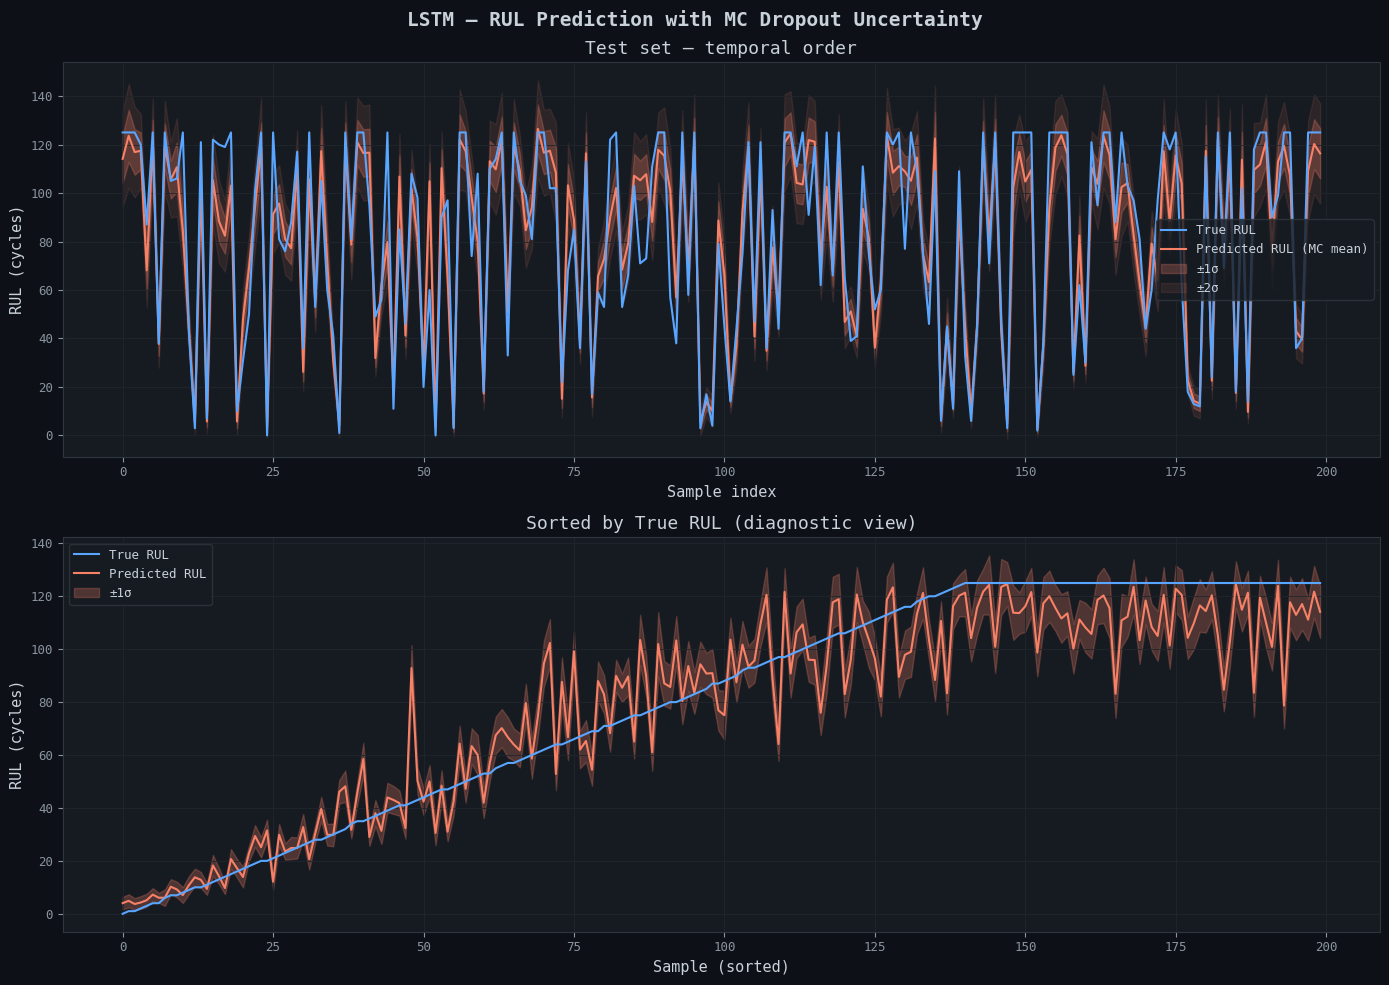

In [13]:
sort_idx   = np.argsort(y_test)
y_sorted   = y_test[sort_idx]
p_sorted   = mean_pred[sort_idx]
u_sorted   = uncertainty[sort_idx]
n200       = min(200, len(y_test))
idx200     = np.linspace(0, len(y_sorted)-1, n200, dtype=int)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.patch.set_facecolor('#0d1117')
fig.suptitle('LSTM — RUL Prediction with MC Dropout Uncertainty',
             fontsize=14, color='#c9d1d9', fontweight='bold')

ax = axes[0]
ax.plot(y_test[:n200],    color=BLUE,   lw=1.5, label='True RUL', zorder=3)
ax.plot(mean_pred[:n200], color=ORANGE, lw=1.5, label='Predicted RUL (MC mean)', zorder=2)
ax.fill_between(range(n200),
                mean_pred[:n200] - uncertainty[:n200],
                mean_pred[:n200] + uncertainty[:n200],
                alpha=0.25, color=ORANGE, label='±1σ')
ax.fill_between(range(n200),
                mean_pred[:n200] - 2*uncertainty[:n200],
                mean_pred[:n200] + 2*uncertainty[:n200],
                alpha=0.10, color=ORANGE, label='±2σ')
ax.set_title('Test set — temporal order'); ax.set_xlabel('Sample index')
ax.set_ylabel('RUL (cycles)'); ax.legend(fontsize=9); ax.grid(True)

ax2 = axes[1]
ax2.plot(y_sorted[idx200], color=BLUE,   lw=1.5, label='True RUL', zorder=3)
ax2.plot(p_sorted[idx200], color=ORANGE, lw=1.5, label='Predicted RUL', zorder=2)
ax2.fill_between(range(n200),
                 p_sorted[idx200] - u_sorted[idx200],
                 p_sorted[idx200] + u_sorted[idx200],
                 alpha=0.25, color=ORANGE, label='±1σ')
ax2.set_title('Sorted by True RUL (diagnostic view)')
ax2.set_xlabel('Sample (sorted)'); ax2.set_ylabel('RUL (cycles)')
ax2.legend(fontsize=9); ax2.grid(True)

plt.tight_layout()
plt.savefig('rul_uncertainty.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()


In [14]:
all_feat_cols = ['cycle'] + \
                [c+'_mean' for c in features] + \
                [c+'_std'  for c in features]

all_units   = df['unit_nr'].unique()
np.random.seed(42)
train_units = np.random.choice(all_units, size=int(0.8*len(all_units)), replace=False)
test_units  = [u for u in all_units if u not in train_units]

tr = df[df['unit_nr'].isin(train_units)]
te = df[df['unit_nr'].isin(test_units)]

scaler_tab = MinMaxScaler()
Xtr = scaler_tab.fit_transform(tr[all_feat_cols])
Xte = scaler_tab.transform(te[all_feat_cols])
ytr = tr['RUL'].values
yte = te['RUL'].values

print(f"Tabular | Train: {Xtr.shape} | Test: {Xte.shape}")


Tabular | Train: (16340, 21) | Test: (4291, 21)


In [16]:
print("Training Random Forest...")
rf_model = RandomForestRegressor(n_estimators=500, max_features=0.5,
                                 random_state=42, n_jobs=-1)
rf_model.fit(Xtr, ytr)

rf_pred  = np.clip(rf_model.predict(Xte), 0, 125)
rf_rmse  = np.sqrt(mean_squared_error(yte, rf_pred))
rf_mae   = mean_absolute_error(yte, rf_pred)
rf_r2    = r2_score(yte, rf_pred)
print(f"RF   RMSE={rf_rmse:.2f}  MAE={rf_mae:.2f}  R2={rf_r2:.4f}")


Training Random Forest...
RF   RMSE=17.67  MAE=12.34  R2=0.8189


In [17]:
print("Training XGBoost...")
xgb_model = XGBRegressor(n_estimators=500, max_depth=6, learning_rate=0.05,
                         subsample=0.8, colsample_bytree=0.8,
                         objective='reg:squarederror', random_state=42,
                         n_jobs=-1, verbosity=0)
xgb_model.fit(Xtr, ytr)

xgb_pred = np.clip(xgb_model.predict(Xte), 0, 125)
xgb_rmse = np.sqrt(mean_squared_error(yte, xgb_pred))
xgb_mae  = mean_absolute_error(yte, xgb_pred)
xgb_r2   = r2_score(yte, xgb_pred)
print(f"XGB  RMSE={xgb_rmse:.2f}  MAE={xgb_mae:.2f}  R2={xgb_r2:.4f}")


Training XGBoost...
XGB  RMSE=18.24  MAE=12.67  R2=0.8070


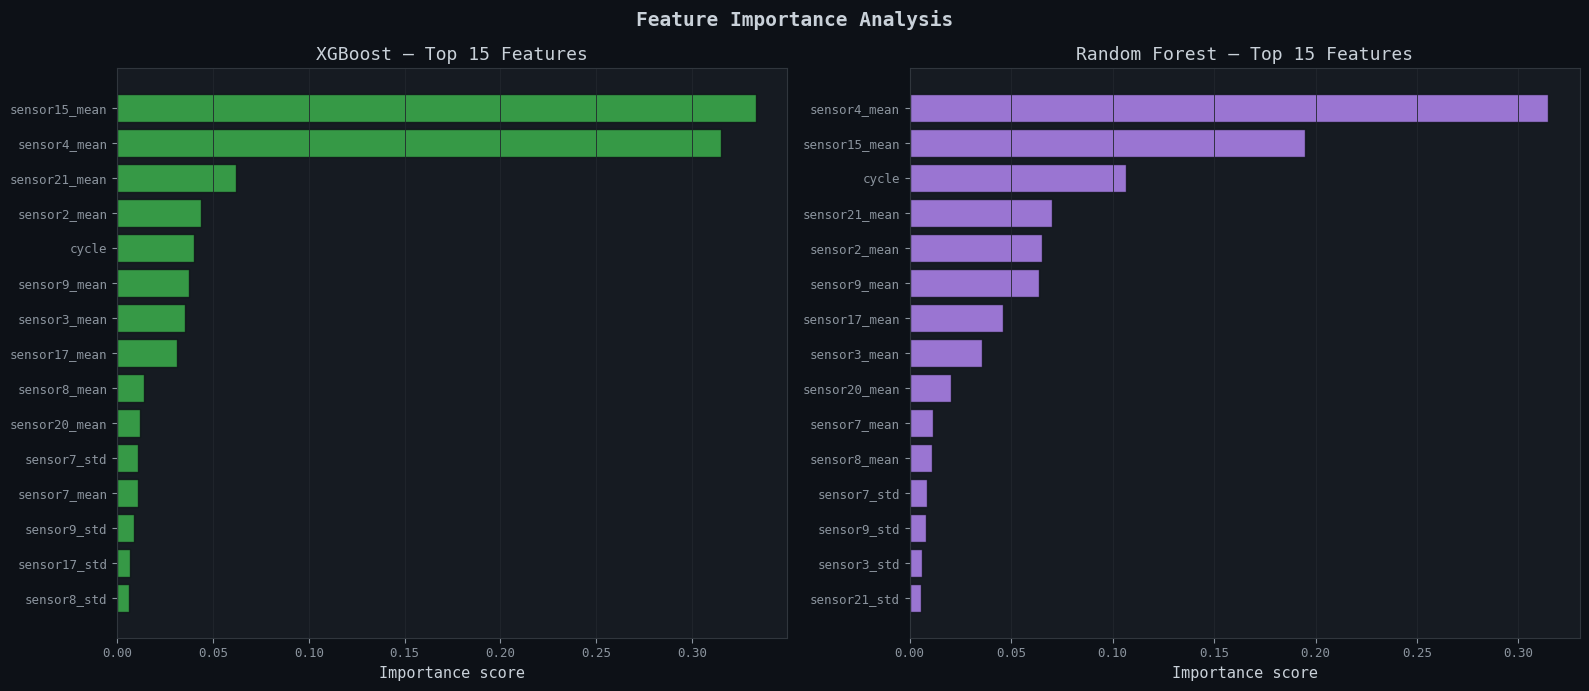

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#0d1117')
fig.suptitle('Feature Importance Analysis', fontsize=14,
             color='#c9d1d9', fontweight='bold')

for ax, (mdl, name, col) in zip(axes, [
    (xgb_model, 'XGBoost',       GREEN),
    (rf_model,  'Random Forest',  PURPLE),
]):
    fi = pd.Series(mdl.feature_importances_, index=all_feat_cols)
    fi = fi.sort_values(ascending=True).tail(15)
    ax.barh(fi.index, fi.values, color=col, alpha=0.8, edgecolor='#0d1117')
    ax.set_title(f'{name} — Top 15 Features')
    ax.set_xlabel('Importance score'); ax.grid(True, axis='x')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()


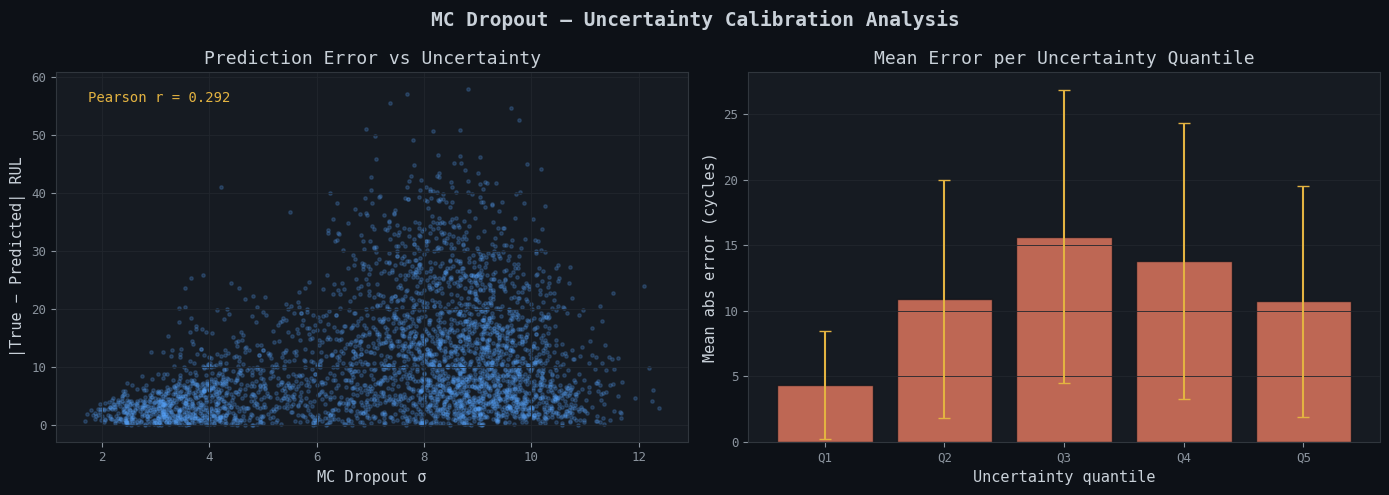

In [19]:
abs_err = np.abs(y_test - mean_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0d1117')
fig.suptitle('MC Dropout — Uncertainty Calibration Analysis',
             fontsize=14, color='#c9d1d9', fontweight='bold')

ax = axes[0]
ax.scatter(uncertainty, abs_err, alpha=0.2, s=6, color=BLUE)
corr_v = np.corrcoef(uncertainty, abs_err)[0, 1]
ax.text(0.05, 0.92, f'Pearson r = {corr_v:.3f}', transform=ax.transAxes,
        color=YELLOW, fontsize=10)
ax.set_title('Prediction Error vs Uncertainty')
ax.set_xlabel('MC Dropout σ'); ax.set_ylabel('|True − Predicted| RUL')
ax.grid(True)

ax2 = axes[1]
bins = np.percentile(uncertainty, np.linspace(0,100,6))
bc, me, se = [], [], []
for lo, hi in zip(bins[:-1], bins[1:]):
    mask = (uncertainty >= lo) & (uncertainty < hi)
    if mask.sum() > 0:
        bc.append((lo+hi)/2)
        me.append(abs_err[mask].mean())
        se.append(abs_err[mask].std())
ax2.bar(range(len(bc)), me, color=ORANGE, alpha=0.75, edgecolor='#0d1117')
ax2.errorbar(range(len(bc)), me, yerr=se, fmt='none', color=YELLOW,
             capsize=4, linewidth=1.5)
ax2.set_xticks(range(len(bc)))
ax2.set_xticklabels([f'Q{i+1}' for i in range(len(bc))])
ax2.set_title('Mean Error per Uncertainty Quantile')
ax2.set_xlabel('Uncertainty quantile'); ax2.set_ylabel('Mean abs error (cycles)')
ax2.grid(True, axis='y')

plt.tight_layout()
plt.savefig('uncertainty_calibration.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()


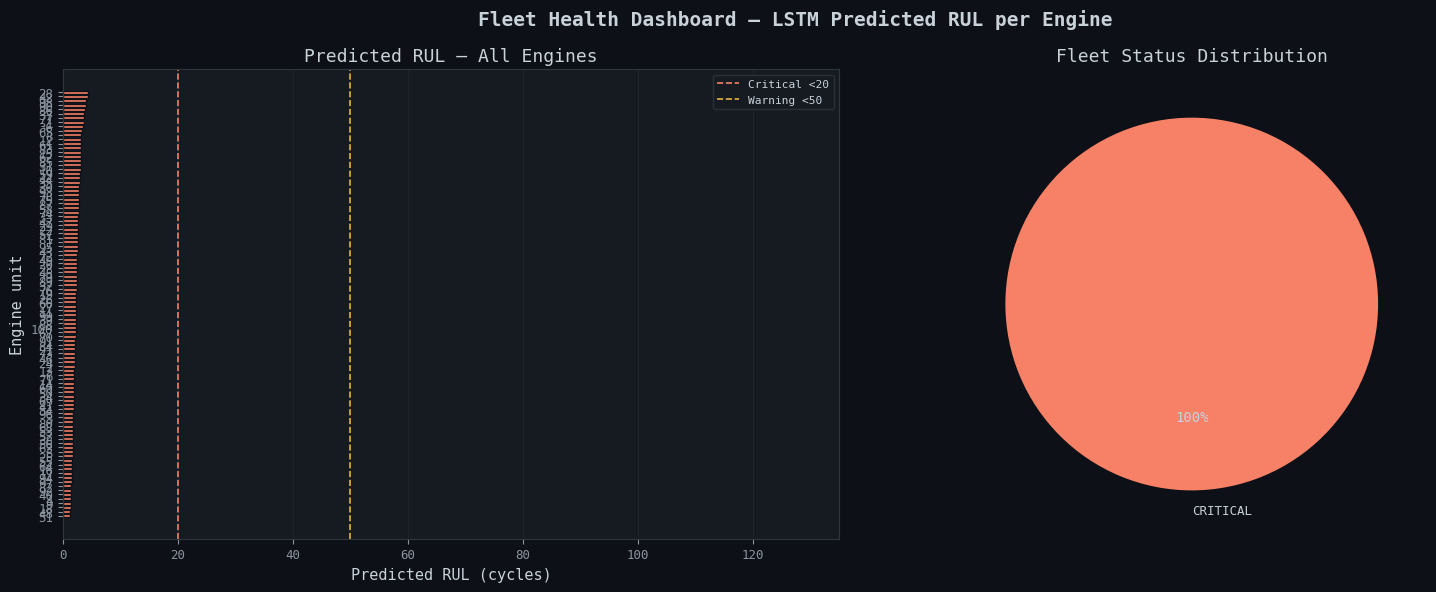

In [20]:
fleet_preds = {}
for unit in df['unit_nr'].unique():
    eng = scaled_df[scaled_df['unit_nr'] == unit].reset_index(drop=True)
    if len(eng) < SEQ_LEN:
        continue
    feats = eng.drop(['unit_nr','cycle','RUL'], axis=1).values
    seq   = feats[-SEQ_LEN:].reshape(1, SEQ_LEN, -1)
    pred  = float(lstm_model.predict(seq, verbose=0).flatten()[0])
    fleet_preds[unit] = float(np.clip(pred, 0, 125))

fleet_df = pd.DataFrame(fleet_preds.items(), columns=['Engine','Predicted_RUL'])
fleet_df['Status'] = fleet_df['Predicted_RUL'].apply(
    lambda r: 'CRITICAL' if r < 20 else ('WARNING' if r < 50 else 'HEALTHY'))
fleet_df = fleet_df.sort_values('Predicted_RUL').reset_index(drop=True)

status_col = {'CRITICAL': ORANGE, 'WARNING': YELLOW, 'HEALTHY': GREEN}
bar_colors = fleet_df['Status'].map(status_col)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0d1117')
fig.suptitle('Fleet Health Dashboard — LSTM Predicted RUL per Engine',
             fontsize=14, color='#c9d1d9', fontweight='bold')

ax = axes[0]
ax.barh(fleet_df['Engine'].astype(str), fleet_df['Predicted_RUL'],
        color=bar_colors, edgecolor='#0d1117', height=0.7)
ax.axvline(20, color=ORANGE, ls='--', lw=1.2, label='Critical <20')
ax.axvline(50, color=YELLOW, ls='--', lw=1.2, label='Warning <50')
ax.set_title('Predicted RUL — All Engines')
ax.set_xlabel('Predicted RUL (cycles)'); ax.set_ylabel('Engine unit')
ax.legend(fontsize=8); ax.grid(True, axis='x'); ax.set_xlim(0, 135)

ax2 = axes[1]
counts = fleet_df['Status'].value_counts()
w_col  = [status_col.get(s, GRAY) for s in counts.index]
wedges, texts, autotexts = ax2.pie(
    counts.values, labels=counts.index, colors=w_col,
    autopct='%1.0f%%', startangle=90,
    wedgeprops=dict(edgecolor='#0d1117', linewidth=2))
for t in texts+autotexts:
    t.set_color('#c9d1d9')
ax2.set_title('Fleet Status Distribution')

plt.tight_layout()
plt.savefig('fleet_health.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()


In [21]:
print("\n" + "="*55)
print("  ROLLS-ROYCE TURBOFAN — FINAL RESULTS SUMMARY")
print("="*55)
print(f"   {'Model':<22} {'RMSE':>7} {'MAE':>7} {'R2':>8}")
print("-"*55)
print(f" {'LSTM (Deep Learning)':<22} {lstm_rmse:>7.2} {xgb_r2:>8.4f}")
print(f" {'XGBoost':<22} {xgb_rmse:>7.2} {xgb_mae:>7.2f} {xgb_r2:>8.4f}")
print(f" {'Random Forest':<22} {rf_rmse:7.2f} {rf_mae:>7.2f} {rf_r2:>8.4f}")
print("="*55)

crit = (fleet_df['Status']=='CRITICAL').sum()
warn = (fleet_df['Status']=='WARNING').sum()
hlth = (fleet_df['Status']=='HEALTHY').sum()
print(f"\n Fleet ({len(fleet_df)} engines):")
print(f"   CRITICAL (RUL<20): {crit}")
print(f"   WARNING  (RUL<50): {warn}")
print(f"   HEALTHY  (RUL>=50): {hlth}")
print("\n Plots saved:")
for f in ['eda_overview','correlation_heatmap','sensor_degradation',
          'lstm-training','lstm_scatter','rul_uncertainty',
          'model_comparison_scatter','model_performance_bars',
          'feature_importance','uncertainty_calibration','fleet_health']:
    print(f"    {f}.png")
print("="*55)


  ROLLS-ROYCE TURBOFAN — FINAL RESULTS SUMMARY
   Model                     RMSE     MAE       R2
-------------------------------------------------------
 LSTM (Deep Learning)   1.5e+01   0.8070
 XGBoost                1.8e+01   12.67   0.8070
 Random Forest            17.67   12.34   0.8189

 Fleet (100 engines):
   CRITICAL (RUL<20): 100
   WARNING  (RUL<50): 0
   HEALTHY  (RUL>=50): 0

 Plots saved:
    eda_overview.png
    correlation_heatmap.png
    sensor_degradation.png
    lstm-training.png
    lstm_scatter.png
    rul_uncertainty.png
    model_comparison_scatter.png
    model_performance_bars.png
    feature_importance.png
    uncertainty_calibration.png
    fleet_health.png
